<a href="https://colab.research.google.com/github/hesther/teaching/blob/main/camlc2026/Workshop_ChemTorch_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop Demo: ChemTorch

Welcome to this workshop on using ChemTorch, a modular python package for machine learning for reaction properties. Let us setup the environment. If Colab prompts you to refresh the session, wait until the command is finished and then do so, and continue with the next cell.

In [1]:
!git clone https://github.com/heid-lab/chemtorch.git
!pip -q install rdkit numpy==1.26.4 scikit-learn pandas torch hydra-core wandb ipykernel
!pip -q install torch_geometric
!pip -q install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.10.0+cpu.html
!pip -q install -e chemtorch

Cloning into 'chemtorch'...
remote: Enumerating objects: 9707, done.
remote: Counting objects: 100% (1203/1203), done.
remote: Compressing objects: 100% (513/513), done.
remote: Total 9707 (delta 776), reused 901 (delta 670), pack-reused 8504 (from 1)
Receiving objects: 100% (9707/9707), 29.81 MiB | 21.62 MiB/s, done.
Resolving deltas: 100% (5910/5910), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is

In [1]:
%cd chemtorch

/content/chemtorch


We will train a directed message passing neural network (D-MPNN) [1] to predict reaction barrier heights of small organic reactions in gas phase.

Specifically, we will look at an experimental database of barrier heights of S$_N$Ar reactions [2]. We will download a processed version from the github repo of this workshop:

In [2]:
!wget https://raw.githubusercontent.com/hesther/teaching/refs/heads/main/camlc2026/snar_reactions.csv

--2026-05-14 17:19:58--  https://raw.githubusercontent.com/hesther/teaching/refs/heads/main/camlc2026/snar_reactions.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 131554 (128K) [text/plain]
Saving to: ‘snar_reactions.csv’

snar_reactions.csv  100%[===================>] 128.47K  --.-KB/s    in 0.01s   

2026-05-14 17:19:59 (10.1 MB/s) - ‘snar_reactions.csv’ saved [131554/131554]



In [3]:
import pandas as pd
df = pd.read_csv("snar_reactions.csv")
df

,AAM,exp_activation_energy
0,[CH3:1][O:2][C:3]1=[N:4][C:5]([O:6][CH3:7])=[N...,20.59
1,[O:1]=[N+:2]([C:4]1=[CH:5][N:6]=[C:7]([C:9]([N...,21.02
2,[CH3:14][O:15][C:16]1=[N:17][C:18]([O:19][CH3:...,18.92
3,[O:7]=[N+:8]([C:10]1=[CH:11][CH:12]=[C:13]([N:...,18.16
4,[CH3:1][O:2][C:3]1=[C:10]([N+:11]([O-:13])=[O:...,16.91
...,...,...
438,[O:1]=[N+:2]([C:4]1=[CH:5][CH:6]=[C:7]([C:16](...,21.03
439,[O:1]=[N+:2]([C:4]1=[CH:5][CH:6]=[C:7]([N:14]=...,19.44
440,[O:7]=[N+:8]([C:10]1=[CH:11][CH:12]=[C:13]([CH...,27.91
441,[CH3:33][O:34][C:8]1=[C:9]([CH:17]=[C:18]([CH:...,20.60


# ChemTorch on the commandline

You can easily train a ChemTorch model, for example, with the preset `+experiment=graph` we obtain a D-MPNN model, and simply have to specificy the data path and column identifiers:

In [4]:
!chemtorch +experiment=graph data_module.data_pipeline.data_source.data_path=snar_reactions.csv data_module.data_pipeline.column_mapper.smiles='AAM' data_module.data_pipeline.column_mapper.label='exp_activation_energy' log=false


 ██████╗██╗  ██╗███████╗███╗   ███╗████████╗ ██████╗ ██████╗  ██████╗██╗  ██╗
██╔════╝██║  ██║██╔════╝████╗ ████║╚══██╔══╝██╔═══██╗██╔══██╗██╔════╝██║  ██║
██║     ███████║█████╗  ██╔████╔██║   ██║   ██║   ██║██████╔╝██║     ███████║
██║     ██╔══██║██╔══╝  ██║╚██╔╝██║   ██║   ██║   ██║██╔══██╗██║     ██╔══██║
╚██████╗██║  ██║███████╗██║ ╚═╝ ██║   ██║   ╚██████╔╝██║  ██║╚██████╗██║  ██║
 ╚═════╝╚═╝  ╚═╝╚══════╝╚═╝     ╚═╝   ╚═╝    ╚═════╝ ╚═╝  ╚═╝ ╚═════╝╚═╝  ╚═╝

[INFO] Precomputed 354/354 samples for train set in 1.40 seconds.
[INFO] Precomputed 44/44 samples for val set in 0.32 seconds.
[INFO] Precomputed 45/45 samples for test set in 0.18 seconds.
┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ GNN              │  305 K │ train │     0 │
│ 1 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 2 │ tra

After a minute or so, you have your very first trained ChemTorch model! For a lot of tasks, this would already be sufficient, and you can check out the documentation for further options. For example, if you would like a GCN instead of the D-MPNN, you simply specify `model=gcn` additionally (other graph neural network options include GAT, GATv2, GatedGCN, and GINE).

#ChemTorch as Python code

Now, for let us take a deeper dive into the ChemTorch pipeline and make our own from scratch:

In [35]:
import os
from copy import deepcopy
from functools import partial

import torch
from lightning import Trainer, seed_everything
from torch_geometric.loader import DataLoader
from torchmetrics import MeanAbsoluteError, MeanSquaredError, MetricCollection

from chemtorch.components.data_pipeline import SimpleDataPipeline
from chemtorch.components.data_pipeline.column_mapper import ColumnFilterAndRename
from chemtorch.components.data_pipeline.data_source import SingleCSVSource
from chemtorch.components.data_pipeline.data_splitter import RatioSplitter

from chemtorch.components.representation.graph import CGR
from chemtorch.components.representation.graph.featurizer import (
    AtomDegreeFeaturizer,
    AtomFormalChargeFeaturizer,
    AtomHCountFeaturizer,
    AtomHybridizationFeaturizer,
    AtomIsAromaticFeaturizer,
    AtomIsInRingFeaturizer,
    BondInRingFeaturizer,
    BondIsConjugatedFeaturizer,
    BondTypeFeaturizer,
    CentiAtomMassFeaturizer,
    FeaturizerCompose,
    OrganicAtomicNumberOneHotFeaturizer,
)

from chemtorch.components.layer import LayerStack
from chemtorch.components.layer.gnn_layer import (
    DMPNNBlock,
    DMPNNConv,
    DMPNNStack,
    EdgeToNodeEmbedding,
)


from chemtorch.components.model import MLP
from chemtorch.components.model.gnn import (
    DirectedEdgeEncoder,
    GNN,
    GlobalPool,
)

from chemtorch.core import DataModule
from chemtorch.core.routine import RegressionRoutine
from chemtorch.core.scheduler import CosineWithWarmupLR
from chemtorch.utils import Standardizer

In [7]:
seed = 0
seed_everything(seed)
torch.use_deterministic_algorithms(True)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = (":4096:8")     # https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility

INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


## 1. Data Pipeline

In ChemTorch, the data pipeline is responsible for loading the raw data and turning into a format that can be consumed by downstream code.

Here is what the `SimpleDataPipeline` does:

- it loads the raw data from a data source, e.g. a CSV file,
- selects/renames the data columns to align with the ChemTorch API,
- splits the data into train/validation/test sets.


In [9]:
DATA_PATH = "snar_reactions.csv"

pipeline = SimpleDataPipeline(
    data_source=SingleCSVSource(data_path=DATA_PATH),
    column_mapper=ColumnFilterAndRename(smiles="AAM", label="exp_activation_energy"),
    data_splitter=RatioSplitter(train_ratio=0.8, val_ratio=0.1, test_ratio=0.1),
)

data_split = pipeline()
data_split.train.head()

,smiles,label
362,[F:5][C:4]1=[N:3][C:2]([F:12])=[C:10]([C:8]([C...,24.66
249,[O:10]=[N+:11]([C:13]1=[CH:14][CH:15]=[C:16]([...,23.04
271,[O:11]=[N+:10]([C:9]1=[CH:8][CH:7]=[C:6]([C:14...,16.13
436,[CH3:1][O:2][C:3]1=[N:4][C:5]([O:6][CH3:7])=[N...,21.20
399,[CH3:21][O:22][C:23]1=[N:24][C:25]([O:26][CH3:...,22.75


## 2. Reaction Representation

One of the most important questions in chemical deep learning is how to represent your molecules/reactions for your desired task. We will be using the Condensed Graph of Reaction (CGR) [3] here. It it a graph overlay of reactant and product graphs where forming/breaking bonds carry special annotations.

As shown in the ChemTorch paper [4], the CGR provides a strong baseline for barrier height prediction but it requires atom mapping.

In ChemTorch, each representation takes in a SMILES string and returns some kind of data object compatible with your model. The CGR representation is initilized with atom and bond featurizers which can be composed. The following featurizers are simple RDKit featurizers preconfigured for organic molecules.

In [10]:
atom_featurizer = FeaturizerCompose(
    [
        OrganicAtomicNumberOneHotFeaturizer(),
        AtomDegreeFeaturizer(),
        AtomFormalChargeFeaturizer(),
        AtomHCountFeaturizer(),
        AtomHybridizationFeaturizer(),
        AtomIsAromaticFeaturizer(),
        CentiAtomMassFeaturizer(),
        AtomIsInRingFeaturizer(),
    ]
)

bond_featurizer = FeaturizerCompose(
    [
        BondTypeFeaturizer(),
        BondIsConjugatedFeaturizer(),
        BondInRingFeaturizer(),
    ]
)

representation = CGR(
    atom_featurizer=atom_featurizer,
    bond_featurizer=bond_featurizer,
)

In [11]:
example_smiles = data_split.train.iloc[0]["smiles"]
example_graph = representation.construct(example_smiles)

print(example_graph)
print("node feature dimension:", example_graph.x.shape[-1])
print("edge feature dimension:", example_graph.edge_attr.shape[-1])

Data(x=[12, 88], edge_index=[2, 24], edge_attr=[24, 22], edge_origin_type=[24], smiles='[F:5][C:4]1=[N:3][C:2]([F:12])=[C:10]([C:8]([Cl:9])=[C:6]1[F:7])[Cl:11].[NH3:1]>>[NH2:1][C:2]1=[N:3][C:4]([F:5])=[C:6]([C:8]([Cl:9])=[C:10]1[Cl:11])[F:7].[FH:12]', atom_origin_type=[12], num_nodes=12)
node feature dimension: 88
edge feature dimension: 22


Our featurization results in 88 node features and 22 edge features.

## 3. DataModule

One of the heart pieces in the ChemTorch pipeline is the `DataModule` which extends PyTorch Lightning’s `lightning.DataModule`. The data module manages data object creation and batching for training/inference.

It is initialized with

- our data pipeline,
- the chosen representation,
- a compatible torch dataloader class, and
- optional data transforms/augmentations.

For graph data we use PyG’s DataLoader, partially configured with the batch size. The data module will use this as a template to create train, validation, and test dataloaders.

In [12]:
dataloader_factory = partial(
    DataLoader,
    batch_size=64,
    num_workers=0,
    pin_memory=False,
)

data_module = DataModule(
    data_pipeline=pipeline,
    representation=representation,
    dataloader_factory=dataloader_factory,
    transform=None,
    augmentations=None
)

In [13]:
batch, labels = next(iter(data_module.train_dataloader()))
print(batch)
print(labels.shape)

DataBatch(x=[1325, 88], edge_index=[2, 2770], edge_attr=[2770, 22], edge_origin_type=[2770], smiles=[64], atom_origin_type=[1325], num_nodes=1325, batch=[1325], ptr=[65])
torch.Size([64])


## 4. D-MPNN Model

ChemTorch supports any type of model compatbile with the PyTorch API.

For GNNs, ChemTorch comes with a ready to use blueprint that is initialized with the following components:

1. `encoder`: turns the node/edge features into learned embeddings.
2. `layer_stack`: applies repeated graph convolutions, in our case, a few blocks of directed message passing.
To increase the expressivity of our GNN, each block adds a residual connection, a 2-layer feedforward network, and dropout.
These are applied after message passing and before ReLU.

3. `pool`: reduces node/edge embeddings to one graph embedding per reaction.
4. `head`: maps the graph embeddings to the regression prediction, in our case a scalar barrier height.

In [14]:
NUM_NODE_FEATURES = 88
NUM_EDGE_FEATURES = 22
DIRECTED_EDGE_ENCODER_IN_CHANNELS = NUM_NODE_FEATURES + NUM_EDGE_FEATURES

HIDDEN_CHANNELS = 128
DEPTH = 3
OUT_CHANNELS = 1

# 1. directed edge encoder
encoder=DirectedEdgeEncoder(
    in_channels=DIRECTED_EDGE_ENCODER_IN_CHANNELS,
    out_channels=HIDDEN_CHANNELS,
)

# 2. directed message passing layer stack
layer_block = DMPNNBlock(
    graph_conv=DMPNNConv(
        in_channels=HIDDEN_CHANNELS,
        out_channels=HIDDEN_CHANNELS,
    ),
    residual=True,
    ffn=True,
    dropout=0.1,
    act="relu",
    hidden_channels=HIDDEN_CHANNELS
)

layer_stack = DMPNNStack(
    dmpnn_blocks=LayerStack(
        layer=layer_block,
        depth=DEPTH,
    ),
    edge_to_node_embedding=EdgeToNodeEmbedding(
        embedding_size=HIDDEN_CHANNELS,
        num_node_features=NUM_NODE_FEATURES,
    ),
)

# 3. pooling function
pool = GlobalPool(aggr="add")

# 4. prediction head
head = MLP(
        in_channels=HIDDEN_CHANNELS,
        hidden_size=HIDDEN_CHANNELS,
        num_hidden_layers=1,
        out_channels=OUT_CHANNELS,
        dropout=0.01,
        act="relu",
    )

# assmeble everything into the GNN
model = GNN(
    encoder=encoder,
    layer_stack=layer_stack,
    pool=pool,
    head=head,
)

print(model)

GNN(
  (encoder): DirectedEdgeEncoder(
    (edge_init): Linear(in_features=110, out_features=128, bias=True)
  )
  (layer_stack): DMPNNStack(
    (dmpnn_blocks): LayerStack(
      (layers): ModuleList(
        (0-2): 3 x DMPNNBlock(
          (graph_conv): DMPNNConv()
          (activation): ReLU()
          (norm): Identity()
          (dropout): Dropout(p=0.1, inplace=False)
          (ffn_norm_in): Identity()
          (ffn_linear1): Linear(in_features=128, out_features=256, bias=True)
          (ffn_linear2): Linear(in_features=256, out_features=128, bias=True)
          (ffn_act_fn): ReLU()
          (ffn_norm_out): Identity()
          (ffn_dropout1): Dropout(p=0.1, inplace=False)
          (ffn_dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (edge_to_node_embedding): EdgeToNodeEmbedding(
      (linear): Linear(in_features=216, out_features=128, bias=True)
      (activation): ReLU()
      (aggregation): SumAggregation()
    )
  )
  (pool): GlobalPool()
  (hea

We can now use our model to make predictions (which are not great because we didn't train yet):

In [15]:
with torch.no_grad():
    predictions = model(deepcopy(batch))

print(predictions.shape)
print(predictions[:10])

torch.Size([64, 1])
tensor([[-0.1383],
        [-0.2651],
        [-0.0176],
        [ 0.2514],
        [ 0.0317],
        [-0.0915],
        [-0.1220],
        [ 0.0427],
        [-0.0949],
        [ 0.2197]])


## 5. Routine

To reduce boilerplate PyTorch code, ChemTorch builds on PyTorch Lightning’s `LightningModule` and provides a common ``Routine abstraction that handles training and inference logic such as metric logging, optimization steps, learning-rate scheduling, and prediction rescaling for regression tasks.

The `Routine` wraps our PyTorch model together with its loss function, optimizer, learning-rate scheduler, metrics, and prediction postprocessing.

The `Standardizer` normalizes targets using statistics computed from the training set and later reverses this transformation to compute metrics and return predictions in the original scale.

In [16]:
# train data statistics from previous experiment
TRAIN_LABEL_MEAN = 21.4
TRAIN_LABEL_STD = 3.9

metrics = {
    "train": MetricCollection(
        {"rmse": MeanSquaredError(squared=False)}
    ),
    "val": MetricCollection(
        {"rmse": MeanSquaredError(squared=False)}
    ),
    "test": MetricCollection(
        {
            "mae": MeanAbsoluteError(),
            "rmse": MeanSquaredError(squared=False),
        }
    ),
}

routine = RegressionRoutine(
    model=model,
    standardizer=Standardizer(mean=TRAIN_LABEL_MEAN, std=TRAIN_LABEL_STD),
    loss=torch.nn.MSELoss(),
    optimizer=partial(
        torch.optim.AdamW,
        lr=0.00053,
        weight_decay=0.0006
    ),
    lr_scheduler={
        "scheduler": partial(
            CosineWithWarmupLR,
            num_warmup_steps=10,
            num_training_steps=100,
            start_factor=1.0e-6,
            end_factor=1.0,
            eta_min=0.0,
        ),
        "interval": "epoch",
        "frequency": 1,
    },
    metrics=metrics,
)

## 6. Trainer

Finally, Lightning’s `Trainer` orchestrates fitting and testing.

For the tutorial we use a maximum of 100 epoch, no logger, and disable checkpointing.

When running a real experiment, we would use a higher maximum number of epochs, the Weights & Biases Logger, and enable checkpointing.

In [17]:
MAX_EPOCHS = 100

trainer = Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    logger=False,
    enable_checkpointing=False,
    gradient_clip_val=1.0,
    log_every_n_steps=1,
)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [18]:
trainer.fit(routine, datamodule=data_module)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ GNN              │  305 K │ train │     0 │
│ 1 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 305 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 305 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 68                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [19]:
trainer.test(routine, datamodule=data_module)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_mae          │    1.0056488513946533     │
│         test_rmse         │     1.325879693031311     │
└───────────────────────────┴───────────────────────────┘

[{'test_mae': 1.0056488513946533, 'test_rmse': 1.325879693031311}]

Output()

Text(0.5, 0, 'Predicted activation energy')

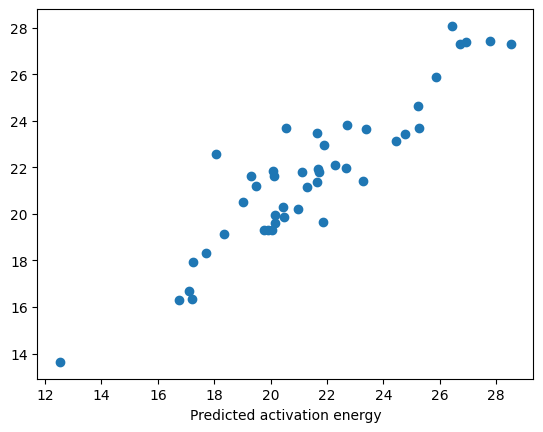

In [79]:
import matplotlib.pyplot as plt
plt.scatter(data_split.test['label'],trainer.predict(routine, data_module.test_dataloader())[0])
plt.xlabel("Experimental activation energy")
plt.xlabel("Predicted activation energy")

Now, you can make any changes to the model, e.g. change the atom/bond featurizer, change the architecture, change individual layers, aggregation, etc. and design the model of your dreams. This is the power of building your own pipeline: You can mix and match any components you like, or implement any custom components.

For example, let us build our own additional atom feature if we expect radicals to be in our dataset:

In [49]:
from rdkit.Chem import Atom

from chemtorch.components.representation.graph.featurizer.featurizer_base import FeaturizerBase


class AtomGetNumRadicalFeaturizer(FeaturizerBase[Atom]):
    """Atom number of radical electrons featurizer."""

    def __init__(self):
        features = [Atom.GetNumRadicalElectrons]
        super().__init__(features)



In [50]:
atom_featurizer = FeaturizerCompose(
    [
        OrganicAtomicNumberOneHotFeaturizer(),
        AtomDegreeFeaturizer(),
        AtomFormalChargeFeaturizer(),
        AtomHCountFeaturizer(),
        AtomHybridizationFeaturizer(),
        AtomIsAromaticFeaturizer(),
        CentiAtomMassFeaturizer(),
        AtomIsInRingFeaturizer(),
        AtomGetNumRadicalFeaturizer(),

    ]
)

representation = CGR(
    atom_featurizer=atom_featurizer,
    bond_featurizer=bond_featurizer,
)

In [64]:
example_smiles = "[CH2:1]>>[CH4:1]"
example_graph = representation.construct(example_smiles)
print(example_graph.x.shape)
example_graph.x[0][:45]

torch.Size([1, 90])


tensor([0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000,
        0.0000, 0.0000, 0.1201, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 2.0000])

Note that ChemTorch also supports other modalities than graph neural networks on graphs: Neural networks on fingerprints, language models on tokens (string representations), or spatial neural networks on 3D coordinates. Consult the documentation or the manuscript for examples!

#References

[1] Yang, K.; Swanson, K.; Jin, W.; Coley, C.; Eiden, P.; Gao, H.; Guzman-Perez, A.; Hopper, T.; Kelley, B.; Mathea, M. Analyzing learned molecular representations for property prediction. J. Chem. Inf. Model. 2019, 59, 3370– 3388, DOI: 10.1021/acs.jcim.9b00237

[2] Jorner, K.; Brinck, T.; Norrby, P.-O.; Buttar, D. Machine learning meets mechanistic modelling for accurate prediction of experimental activation energies. Chem. Sci. 2021, 12, 1163-1175, DOI: 10.1039/D0SC04896H

[3] Heid, E.; Green, W. H. Machine learning of reaction properties via learned representations of the condensed graph of reaction. J. Chem. Inf. Model. 2022, 62, 2101– 2110, DOI: 10.1021/acs.jcim.1c00975

[4] De Landsheere, J.; Zamyatin, A.; Karwounopoulo, J.; Heid, E. ChemTorch: A Deep Learning Framework for Benchmarking and Developing Chemical Reaction Property Prediction Models. J. Chem. Inf. Model. 2026, 66, 2434-2442, DOI: 10.1021/acs.jcim.5c02645